<a href="https://colab.research.google.com/github/bintangfikrif/Klasifikasi-Makanan-Daerah/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Klasifikasi Makanan Daerah Indonesia

Notebook ini berisi implementasi klasifikasi gambar makanan Indonesia menggunakan 3 model pretrained terbaik:
1. EfficientNet-V2-S (21.5M parameters)
2. EfficientNet-B4 (19.3M parameters)
3. EfficientNet-B3 (12.2M parameters)

Dataset: 5 kelas makanan Indonesia (bakso, gado_gado, nasi_goreng, rendang, soto_ayam)

In [ ]:
# Instalasi dependensi
# !pip install torch torchvision torchinfo pandas pillow tqdm matplotlib seaborn scikit-learn

In [ ]:
# !pip install scikit-learn

In [ ]:
# Import library yang diperlukan
import os
import random
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
from torchinfo import summary

# Set seed untuk reproduksibilitas
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Konfigurasi device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Menggunakan device: {device}")

# Konfigurasi kelas
CLASS_NAMES = ["bakso", "gado_gado", "nasi_goreng", "rendang", "soto_ayam"]
NUM_CLASSES = len(CLASS_NAMES)
print(f"Jumlah kelas: {NUM_CLASSES}")
print(f"Nama kelas: {CLASS_NAMES}")

# Konfigurasi plotting
plt.style.use('default')
sns.set_palette("husl")

Menggunakan device: cuda
Jumlah kelas: 5
Nama kelas: ['bakso', 'gado_gado', 'nasi_goreng', 'rendang', 'soto_ayam']


## DataReader - Kelas untuk Membaca dan Memproses Dataset

In [ ]:
class DataReader:
    def __init__(self, data_dir, csv_file):
        self.data_dir = data_dir
        self.csv_file = csv_file
        self.df = None
        self.class_to_idx = {cls: idx for idx, cls in enumerate(CLASS_NAMES)}

    def load_data(self):
        """Memuat data dari file CSV"""
        self.df = pd.read_csv(self.csv_file)
        print(f"Total data: {len(self.df)}")

        # Tampilkan distribusi kelas jika ada label
        if 'label' in self.df.columns and not self.df['label'].isna().all():
            print("\nDistribusi kelas:")
            print(self.df['label'].value_counts().sort_index())

        return self.df

    def get_image_path(self, filename):
        """Mendapatkan path lengkap file gambar"""
        return os.path.join(self.data_dir, filename)

    def verify_images(self):
        """Memverifikasi keberadaan file gambar"""
        missing_files = []
        for filename in self.df['filename']:
            img_path = self.get_image_path(filename)
            if not os.path.exists(img_path):
                missing_files.append(filename)

        if missing_files:
            print(f"File gambar yang tidak ditemukan: {len(missing_files)}")
            print(missing_files[:10])  # Tampilkan 10 pertama
        else:
            print("Semua file gambar ditemukan")

        return missing_files

    def visualize_data_distribution(self):
        """Visualisasi distribusi data per kelas"""
        if 'label' in self.df.columns and not self.df['label'].isna().all():
            plt.figure(figsize=(12, 8))

            # Subplot 1: Bar chart distribusi kelas
            plt.subplot(2, 2, 1)
            class_counts = self.df['label'].value_counts().sort_index()
            bars = plt.bar(class_counts.index, class_counts.values, color=sns.color_palette("husl", len(class_counts)))
            plt.title('Distribusi Jumlah Data per Kelas')
            plt.xlabel('Kelas Makanan')
            plt.ylabel('Jumlah Data')
            plt.xticks(rotation=45)

            # Tambahkan nilai di atas bar
            for bar, value in zip(bars, class_counts.values):
                plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                        str(value), ha='center', va='bottom')

            # Subplot 2: Pie chart distribusi kelas
            plt.subplot(2, 2, 2)
            plt.pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
                   colors=sns.color_palette("husl", len(class_counts)))
            plt.title('Persentase Distribusi Kelas')

            # Subplot 3: Histogram ukuran dataset
            plt.subplot(2, 2, 3)
            plt.bar(['Total Data'], [len(self.df)], color='skyblue', width=0.5)
            plt.title(f'Total Dataset: {len(self.df)} gambar')
            plt.ylabel('Jumlah Gambar')
            for i, v in enumerate([len(self.df)]):
                plt.text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')

            # Subplot 4: Statistik kelas
            plt.subplot(2, 2, 4)
            stats_data = {
                'Mean': class_counts.mean(),
                'Std': class_counts.std(),
                'Min': class_counts.min(),
                'Max': class_counts.max()
            }
            bars = plt.bar(stats_data.keys(), stats_data.values(), color='lightcoral')
            plt.title('Statistik Distribusi Kelas')
            plt.ylabel('Nilai')
            for bar, value in zip(bars, stats_data.values()):
                plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                        f'{value:.1f}', ha='center', va='bottom')

            plt.tight_layout()
            plt.show()

            # Print statistik
            print(f"\nStatistik distribusi kelas:")
            print(f"Mean: {class_counts.mean():.1f}")
            print(f"Standard Deviation: {class_counts.std():.1f}")
            print(f"Min: {class_counts.min()}")
            print(f"Max: {class_counts.max()}")
            print(f"Range: {class_counts.max() - class_counts.min()}")

        else:
            print("Data tidak memiliki label untuk divisualisasikan")

    def show_sample_images(self, samples_per_class=3):
        """Menampilkan contoh gambar dari setiap kelas"""
        if 'label' in self.df.columns and not self.df['label'].isna().all():
            unique_classes = sorted(self.df['label'].unique())

            fig, axes = plt.subplots(len(unique_classes), samples_per_class,
                                   figsize=(samples_per_class * 3, len(unique_classes) * 3))

            if len(unique_classes) == 1:
                axes = axes.reshape(1, -1)

            for class_idx, class_name in enumerate(unique_classes):
                class_data = self.df[self.df['label'] == class_name].sample(n=min(samples_per_class, len(self.df[self.df['label'] == class_name])), random_state=42)

                for img_idx, (_, row) in enumerate(class_data.iterrows()):
                    if img_idx >= samples_per_class:
                        break

                    img_path = self.get_image_path(row['filename'])

                    try:
                        image = Image.open(img_path).convert('RGB')
                        axes[class_idx, img_idx].imshow(image)
                        axes[class_idx, img_idx].set_title(f'{class_name}\n{row["filename"]}', fontsize=10)
                        axes[class_idx, img_idx].axis('off')
                    except Exception as e:
                        axes[class_idx, img_idx].text(0.5, 0.5, f'Error loading\n{row["filename"]}',
                                                    ha='center', va='center', transform=axes[class_idx, img_idx].transAxes)
                        axes[class_idx, img_idx].set_title(f'{class_name} - Error', fontsize=10)
                        axes[class_idx, img_idx].axis('off')

                # Sembunyikan subplot kosong jika ada
                for img_idx in range(len(class_data), samples_per_class):
                    axes[class_idx, img_idx].axis('off')

            plt.suptitle(f'Contoh Gambar Dataset ({samples_per_class} per kelas)', fontsize=16)
            plt.tight_layout()
            plt.show()
        else:
            print("Data tidak memiliki label untuk menampilkan contoh gambar")

    def analyze_image_properties(self, sample_size=100):
        """Analisis properti gambar (ukuran, format, dll)"""
        print("Menganalisis properti gambar...")

        # Sample random images untuk analisis
        sample_df = self.df.sample(n=min(sample_size, len(self.df)), random_state=42)

        widths = []
        heights = []
        formats = []
        file_sizes = []

        for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Menganalisis gambar"):
            img_path = self.get_image_path(row['filename'])

            try:
                # Ukuran file
                file_size = os.path.getsize(img_path)
                file_sizes.append(file_size / 1024)  # KB

                # Buka gambar untuk mendapatkan dimensi dan format
                with Image.open(img_path) as img:
                    widths.append(img.width)
                    heights.append(img.height)
                    formats.append(img.format)

            except Exception as e:
                print(f"Error processing {row['filename']}: {e}")

        if widths:
            # Visualisasi analisis
            fig, axes = plt.subplots(2, 2, figsize=(15, 10))

            # Distribusi lebar gambar
            axes[0, 0].hist(widths, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
            axes[0, 0].set_title('Distribusi Lebar Gambar')
            axes[0, 0].set_xlabel('Lebar (pixel)')
            axes[0, 0].set_ylabel('Frekuensi')
            axes[0, 0].axvline(np.mean(widths), color='red', linestyle='--', label=f'Mean: {np.mean(widths):.0f}')
            axes[0, 0].legend()

            # Distribusi tinggi gambar
            axes[0, 1].hist(heights, bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
            axes[0, 1].set_title('Distribusi Tinggi Gambar')
            axes[0, 1].set_xlabel('Tinggi (pixel)')
            axes[0, 1].set_ylabel('Frekuensi')
            axes[0, 1].axvline(np.mean(heights), color='red', linestyle='--', label=f'Mean: {np.mean(heights):.0f}')
            axes[0, 1].legend()

            # Scatter plot lebar vs tinggi
            axes[1, 0].scatter(widths, heights, alpha=0.6, color='purple')
            axes[1, 0].set_title('Lebar vs Tinggi Gambar')
            axes[1, 0].set_xlabel('Lebar (pixel)')
            axes[1, 0].set_ylabel('Tinggi (pixel)')

            # Distribusi ukuran file
            axes[1, 1].hist(file_sizes, bins=20, alpha=0.7, color='orange', edgecolor='black')
            axes[1, 1].set_title('Distribusi Ukuran File')
            axes[1, 1].set_xlabel('Ukuran File (KB)')
            axes[1, 1].set_ylabel('Frekuensi')
            axes[1, 1].axvline(np.mean(file_sizes), color='red', linestyle='--', label=f'Mean: {np.mean(file_sizes):.0f}KB')
            axes[1, 1].legend()

            plt.tight_layout()
            plt.show()

            # Print statistik
            print(f"\nStatistik properti gambar (berdasarkan {len(widths)} sampel):")
            print(f"Lebar - Mean: {np.mean(widths):.0f}, Std: {np.std(widths):.0f}, Min: {min(widths)}, Max: {max(widths)}")
            print(f"Tinggi - Mean: {np.mean(heights):.0f}, Std: {np.std(heights):.0f}, Min: {min(heights)}, Max: {max(heights)}")
            print(f"Ukuran File - Mean: {np.mean(file_sizes):.0f}KB, Std: {np.std(file_sizes):.0f}KB")

            # Analisis format
            format_counts = pd.Series(formats).value_counts()
            print(f"\nFormat gambar:")
            for fmt, count in format_counts.items():
                print(f"  {fmt}: {count} ({count/len(formats)*100:.1f}%)")

# Inisialisasi DataReader untuk data training
train_reader = DataReader('train', 'train.csv')
train_df = train_reader.load_data()
train_reader.verify_images()

# Inisialisasi DataReader untuk data testing
test_reader = DataReader('test', 'test.csv')
test_df = test_reader.load_data()
test_reader.verify_images()

Total data: 1108

Distribusi kelas:
label
bakso          220
gado_gado      215
nasi_goreng    234
rendang        227
soto_ayam      212
Name: count, dtype: int64
Semua file gambar ditemukan
Total data: 277
File gambar yang tidak ditemukan: 277
['0001.jpg', '0002.jpg', '0003.jpg', '0004.jpg', '0005.jpg', '0006.jpg', '0007.jpg', '0008.jpg', '0009.jpg', '0010.jpg']


['0001.jpg',
 '0002.jpg',
 '0003.jpg',
 '0004.jpg',
 '0005.jpg',
 '0006.jpg',
 '0007.jpg',
 '0008.jpg',
 '0009.jpg',
 '0010.jpg',
 '0011.jpg',
 '0012.jpg',
 '0013.jpg',
 '0014.jpg',
 '0015.jpg',
 '0016.jpg',
 '0017.jpg',
 '0018.jpg',
 '0019.jpg',
 '0020.jpg',
 '0021.jpg',
 '0022.jpg',
 '0023.jpg',
 '0024.jpg',
 '0025.jpg',
 '0026.jpg',
 '0027.jpg',
 '0028.jpg',
 '0029.jpg',
 '0030.jpg',
 '0031.jpg',
 '0032.jpg',
 '0033.jpg',
 '0034.jpg',
 '0035.jpg',
 '0036.jpg',
 '0037.jpg',
 '0038.jpg',
 '0039.jpg',
 '0040.jpg',
 '0041.jpg',
 '0042.jpg',
 '0043.jpg',
 '0044.jpg',
 '0045.jpg',
 '0046.jpg',
 '0047.jpg',
 '0048.jpg',
 '0049.jpg',
 '0050.jpg',
 '0051.jpg',
 '0052.jpg',
 '0053.jpg',
 '0054.jpg',
 '0055.jpg',
 '0056.jpg',
 '0057.jpg',
 '0058.jpg',
 '0059.jpg',
 '0060.jpg',
 '0061.jpg',
 '0062.jpg',
 '0063.jpg',
 '0064.jpg',
 '0065.jpg',
 '0066.jpg',
 '0067.jpg',
 '0068.jpg',
 '0069.jpg',
 '0070.jpg',
 '0071.jpg',
 '0072.jpg',
 '0073.jpg',
 '0074.jpg',
 '0075.jpg',
 '0076.jpg',
 '0077.jpg',

Analisis Properti Gambar
Menganalisis properti gambar...


Menganalisis gambar: 100%|██████████| 150/150 [00:00<00:00, 653.19it/s]


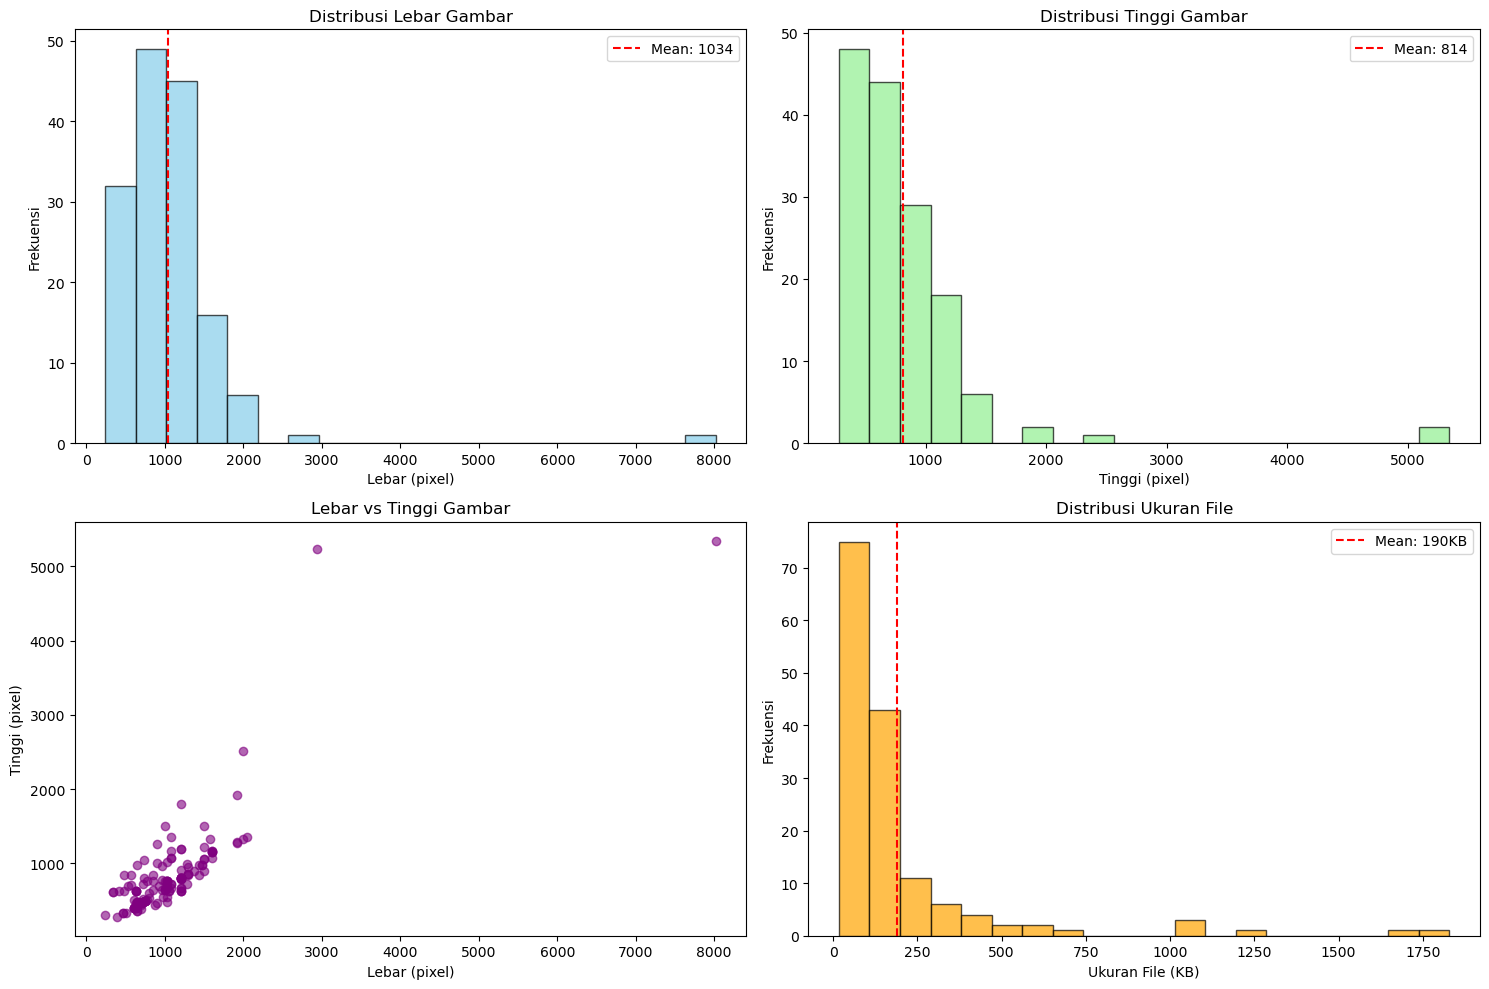


Statistik properti gambar (berdasarkan 150 sampel):
Lebar - Mean: 1034, Std: 704, Min: 240, Max: 8021
Tinggi - Mean: 814, Std: 621, Min: 280, Max: 5348
Ukuran File - Mean: 190KB, Std: 267KB

Format gambar:
  JPEG: 139 (92.7%)
  WEBP: 9 (6.0%)
  PNG: 2 (1.3%)


In [ ]:
# Analisis properti gambar (ukuran, format, dll)
print("Analisis Properti Gambar")
print("="*50)
train_reader.analyze_image_properties(sample_size=150)

Contoh Gambar dari Setiap Kelas


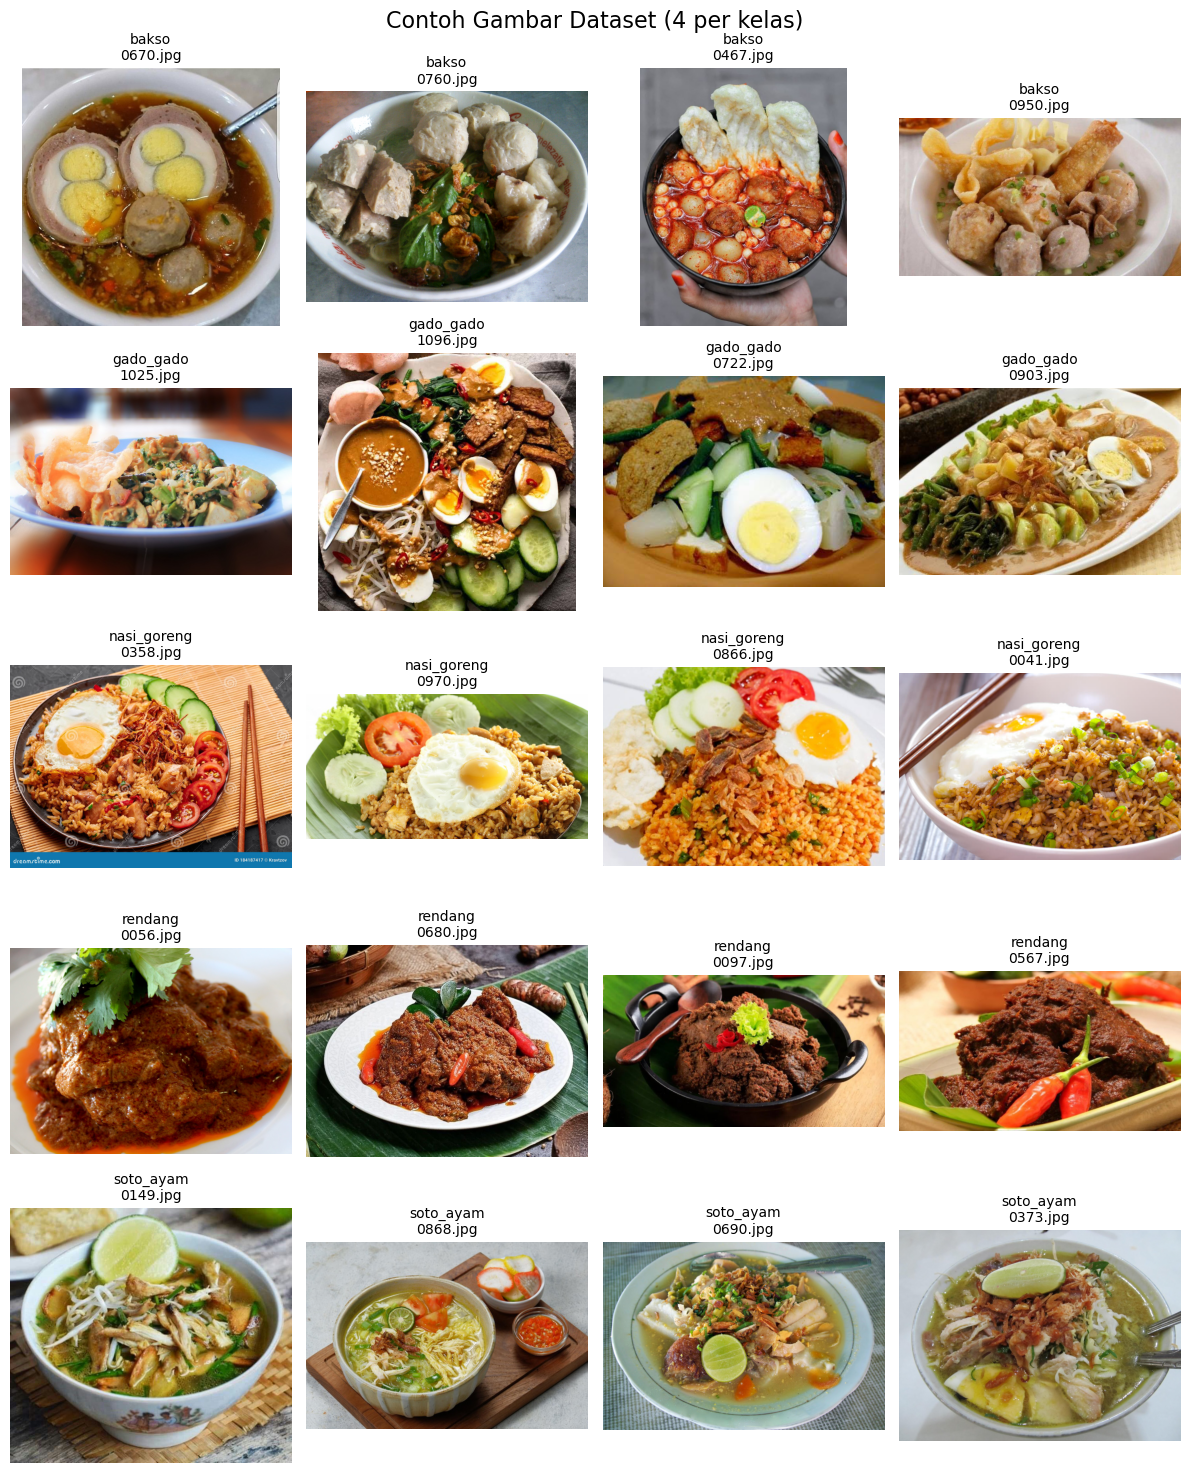

In [ ]:
# Tampilkan contoh gambar dari setiap kelas
print("Contoh Gambar dari Setiap Kelas")
print("="*50)
train_reader.show_sample_images(samples_per_class=4)

Visualisasi Distribusi Data Training


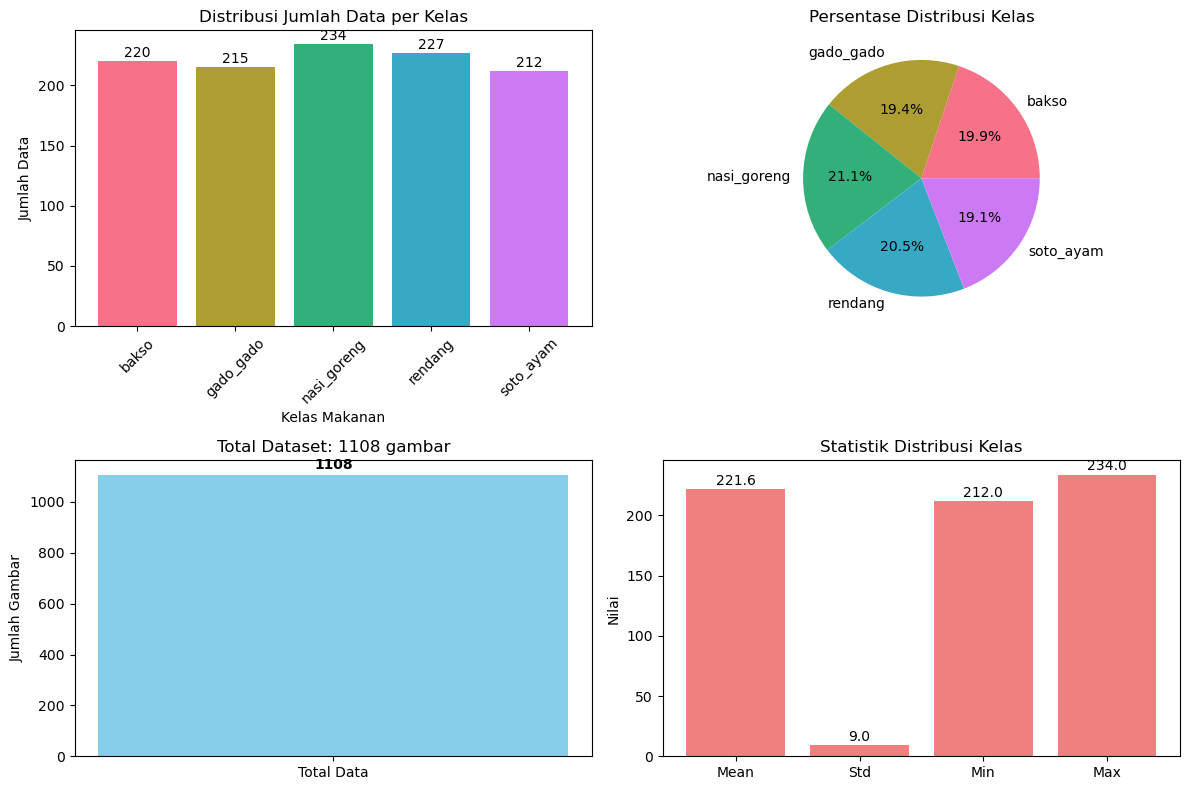


Statistik distribusi kelas:
Mean: 221.6
Standard Deviation: 9.0
Min: 212
Max: 234
Range: 22


In [ ]:
# Visualisasi distribusi data training
print("Visualisasi Distribusi Data Training")
print("="*50)
train_reader.visualize_data_distribution()

## Visualisasi dan Analisis Dataset

In [ ]:
class FoodDataset(Dataset):
    def __init__(self, dataframe, data_dir, transform=None, is_test=False):
        self.df = dataframe
        self.data_dir = data_dir
        self.transform = transform
        self.is_test = is_test
        self.class_to_idx = {cls: idx for idx, cls in enumerate(CLASS_NAMES)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.data_dir, row['filename'])

        # Buka gambar
        image = Image.open(img_path).convert('RGB')

        # Aplikasikan transformasi
        if self.transform:
            image = self.transform(image)

        if self.is_test:
            return image, row['filename']
        else:
            label = self.class_to_idx[row['label']]
            return image, label

# Definisi transformasi data
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Transformasi data berhasil didefinisikan")

Transformasi data berhasil didefinisikan


## Model - Kelas untuk Mendefinisikan Model

In [ ]:
class Model:
    def __init__(self, model_name, num_classes=5):
        self.model_name = model_name
        self.num_classes = num_classes
        self.model = None

    def create_model(self):
        """Membuat model berdasarkan nama model"""
        if self.model_name == 'efficientnet_v2_s':
            self.model = models.efficientnet_v2_s(weights='IMAGENET1K_V1')
            in_features = self.model.classifier[1].in_features
            self.model.classifier[1] = nn.Linear(in_features, self.num_classes)

        elif self.model_name == 'efficientnet_b4':
            self.model = models.efficientnet_b4(weights='IMAGENET1K_V1')
            in_features = self.model.classifier[1].in_features
            self.model.classifier[1] = nn.Linear(in_features, self.num_classes)

        elif self.model_name == 'efficientnet_b3':
            self.model = models.efficientnet_b3(weights='IMAGENET1K_V1')
            in_features = self.model.classifier[1].in_features
            self.model.classifier[1] = nn.Linear(in_features, self.num_classes)

        else:
            raise ValueError(f"Model {self.model_name} tidak didukung")

        return self.model

    def get_model_info(self):
        """Menampilkan informasi model"""
        if self.model is None:
            self.create_model()

        print(f"\nModel: {self.model_name}")
        print("="*50)

        # Hitung total parameter
        total_params = sum(p.numel() for p in self.model.parameters())
        trainable_params = sum(p.numel() for p in self.model.parameters() if p.requires_grad)

        print(f"Total parameter: {total_params:,}")
        print(f"Parameter yang dapat dilatih: {trainable_params:,}")
        print(f"Parameter dalam jutaan: {total_params/1e6:.2f}M")

        # Verifikasi batas parameter
        if total_params < 26_000_000:
            print("Model memenuhi batas parameter < 26M")
        else:
            print("PERINGATAN: Model melebihi batas parameter 26M")

        # Tampilkan summary model
        try:
            summary(self.model, input_size=(1, 3, 224, 224))
        except:
            print("Tidak dapat menampilkan summary model")

        return self.model

# Test ketiga model
model_names = ['efficientnet_v2_s', 'efficientnet_b4', 'efficientnet_b3']

for model_name in model_names:
    model_wrapper = Model(model_name, NUM_CLASSES)
    model_wrapper.get_model_info()


Model: efficientnet_v2_s
Total parameter: 20,183,893
Parameter yang dapat dilatih: 20,183,893
Parameter dalam jutaan: 20.18M
Model memenuhi batas parameter < 26M

Model: efficientnet_b4
Total parameter: 17,557,581
Parameter yang dapat dilatih: 17,557,581
Parameter dalam jutaan: 17.56M
Model memenuhi batas parameter < 26M

Model: efficientnet_b3
Total parameter: 10,703,917
Parameter yang dapat dilatih: 10,703,917
Parameter dalam jutaan: 10.70M
Model memenuhi batas parameter < 26M


## Train - Kelas untuk Melatih Model

In [ ]:
class Train:
    def __init__(self, model, device, num_classes=5):
        self.model = model
        self.device = device
        self.num_classes = num_classes
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = None
        self.scheduler = None

    def setup_optimizer(self, learning_rate=0.001):
        """Setup optimizer dan scheduler"""
        self.optimizer = optim.AdamW(self.model.parameters(), lr=learning_rate, weight_decay=0.01)
        self.scheduler = optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=10, eta_min=1e-6)

    def train_epoch(self, train_loader):
        """Melatih model untuk satu epoch"""
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        progress_bar = tqdm(train_loader, desc='Training')
        for batch_idx, (data, target) in enumerate(progress_bar):
            data, target = data.to(self.device), target.to(self.device)

            self.optimizer.zero_grad()
            output = self.model(data)
            loss = self.criterion(output, target)
            loss.backward()
            self.optimizer.step()

            running_loss += loss.item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += target.size(0)

            # Update progress bar
            progress_bar.set_postfix({
                'Loss': f'{running_loss/(batch_idx+1):.4f}',
                'Acc': f'{100.*correct/total:.2f}%'
            })

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100. * correct / total

        return epoch_loss, epoch_acc

    def validate(self, val_loader):
        """Validasi model"""
        self.model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            progress_bar = tqdm(val_loader, desc='Validation')
            for data, target in progress_bar:
                data, target = data.to(self.device), target.to(self.device)
                output = self.model(data)
                val_loss += self.criterion(output, target).item()
                pred = output.argmax(dim=1, keepdim=True)
                correct += pred.eq(target.view_as(pred)).sum().item()
                total += target.size(0)

                progress_bar.set_postfix({
                    'Val_Acc': f'{100.*correct/total:.2f}%'
                })

        val_loss /= len(val_loader)
        val_acc = 100. * correct / total

        return val_loss, val_acc

    def train_model(self, train_loader, val_loader, epochs=10):
        """Melatih model untuk beberapa epoch"""
        best_val_acc = 0.0
        train_losses = []
        train_accs = []
        val_losses = []
        val_accs = []

        print(f"Memulai training untuk {epochs} epochs...")

        for epoch in range(epochs):
            print(f"\nEpoch {epoch+1}/{epochs}")
            print("-" * 50)

            # Training
            train_loss, train_acc = self.train_epoch(train_loader)

            # Validation
            val_loss, val_acc = self.validate(val_loader)

            # Update scheduler
            self.scheduler.step()

            # Simpan metrics
            train_losses.append(train_loss)
            train_accs.append(train_acc)
            val_losses.append(val_loss)
            val_accs.append(val_acc)

            print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
            print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
            print(f"Learning Rate: {self.optimizer.param_groups[0]['lr']:.6f}")

            # Simpan model terbaik
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                print(f"Model terbaik baru! Akurasi validasi: {val_acc:.2f}%")

        print(f"\nTraining selesai. Akurasi validasi terbaik: {best_val_acc:.2f}%")

        return {
            'train_losses': train_losses,
            'train_accs': train_accs,
            'val_losses': val_losses,
            'val_accs': val_accs,
            'best_val_acc': best_val_acc
        }

print("Kelas Train berhasil didefinisikan")

Kelas Train berhasil didefinisikan


## Persiapan Data untuk Training

In [ ]:
# Split data training menjadi train dan validation
from sklearn.model_selection import train_test_split

train_df_split, val_df_split = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['label']
)

print(f"Data training: {len(train_df_split)}")
print(f"Data validasi: {len(val_df_split)}")

# Buat dataset
train_dataset = FoodDataset(train_df_split, 'train', transform=train_transform)
val_dataset = FoodDataset(val_df_split, 'train', transform=val_transform)
test_dataset = FoodDataset(test_df, 'test', transform=val_transform, is_test=True)

# Buat dataloader dengan pengaturan worker yang aman untuk Windows
batch_size = 32
# Gunakan 0 workers di Windows untuk menghindari multiprocessing issues
num_workers = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"Batch size: {batch_size}")
print(f"Num workers: {num_workers} (aman untuk Windows)")
print(f"Total batch training: {len(train_loader)}")
print(f"Total batch validasi: {len(val_loader)}")
print(f"Total batch testing: {len(test_loader)}")

# Tips optimasi untuk Windows
print(f"\\nOptimasi:")
print(f"- Pin memory: {torch.cuda.is_available()}")
print(f"- CUDA tersedia: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"- GPU: {torch.cuda.get_device_name(0)}")
    print(f"- CUDA Memory: {torch.cuda.get_device_properties(0).total_memory // 1024**3} GB")

Data training: 886
Data validasi: 222
Batch size: 32
Num workers: 0 (aman untuk Windows)
Total batch training: 28
Total batch validasi: 7
Total batch testing: 9
\nOptimasi:
- Pin memory: True
- CUDA tersedia: True
- GPU: NVIDIA GeForce GTX 1650
- CUDA Memory: 3 GB


## Training Model EfficientNet-V2-S

In [ ]:
# Model 1: EfficientNet-V2-S
print("="*60)
print("TRAINING MODEL 1: EfficientNet-V2-S")
print("="*60)

model1_wrapper = Model('efficientnet_v2_s', NUM_CLASSES)
model1 = model1_wrapper.create_model()
model1 = model1.to(device)

# Setup training
trainer1 = Train(model1, device, NUM_CLASSES)
trainer1.setup_optimizer(learning_rate=0.001)

# Training
results1 = trainer1.train_model(train_loader, val_loader, epochs=8)

# Simpan model
torch.save(model1.state_dict(), 'efficientnet_v2_s_weights.pth')
print("Model EfficientNet-V2-S disimpan sebagai 'efficientnet_v2_s_weights.pth'")

TRAINING MODEL 1: EfficientNet-V2-S
Memulai training untuk 8 epochs...

Epoch 1/8
--------------------------------------------------


Training:  79%|███████▊  | 22/28 [02:56<00:36,  6.15s/it, Loss=0.6562, Acc=75.71%]c:\Users\ferda\miniconda3\envs\deeplearning\lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Validation: 100%|██████████| 7/7 [00:14<00:00,  2.14s/it, Val_Acc=85.14%]


Train Loss: 0.6046, Train Acc: 77.77%
Val Loss: 0.6848, Val Acc: 85.14%
Learning Rate: 0.000976
Model terbaik baru! Akurasi validasi: 85.14%

Epoch 2/8
--------------------------------------------------


Validation: 100%|██████████| 7/7 [00:11<00:00,  1.63s/it, Val_Acc=67.12%]


Train Loss: 0.3074, Train Acc: 91.20%
Val Loss: 1.3988, Val Acc: 67.12%
Learning Rate: 0.000905

Epoch 3/8
--------------------------------------------------


...

Train Loss: 0.0728, Train Acc: 97.74%
Val Loss: 0.0924, Val Acc: 97.75%
Learning Rate: 0.000346
Model terbaik baru! Akurasi validasi: 97.75%

Epoch 7/8
--------------------------------------------------


Validation: 100%|██████████| 7/7 [00:11<00:00,  1.59s/it, Val_Acc=96.85%]


Train Loss: 0.0362, Train Acc: 98.87%
Val Loss: 0.0989, Val Acc: 96.85%
Learning Rate: 0.000207

Epoch 8/8
--------------------------------------------------


Validation: 100%|██████████| 7/7 [00:12<00:00,  1.76s/it, Val_Acc=96.85%]


Train Loss: 0.0433, Train Acc: 98.53%
Val Loss: 0.0792, Val Acc: 96.85%
Learning Rate: 0.000096

Training selesai. Akurasi validasi terbaik: 97.75%
Model EfficientNet-V2-S disimpan sebagai 'efficientnet_v2_s_weights.pth'


## Training Model EfficientNet-B4

In [ ]:
# Model 2: EfficientNet-B4
print("="*60)
print("TRAINING MODEL 2: EfficientNet-B4")
print("="*60)

model2_wrapper = Model('efficientnet_b4', NUM_CLASSES)
model2 = model2_wrapper.create_model()
model2 = model2.to(device)

# Setup training
trainer2 = Train(model2, device, NUM_CLASSES)
trainer2.setup_optimizer(learning_rate=0.001)

# Training
results2 = trainer2.train_model(train_loader, val_loader, epochs=8)

# Simpan model
torch.save(model2.state_dict(), 'efficientnet_b4_weights.pth')
print("Model EfficientNet-B4 disimpan sebagai 'efficientnet_b4_weights.pth'")

TRAINING MODEL 2: EfficientNet-B4
Memulai training untuk 8 epochs...

Epoch 1/8
--------------------------------------------------


Validation: 100%|██████████| 7/7 [00:21<00:00,  3.11s/it, Val_Acc=93.69%] 


Train Loss: 1.1250, Train Acc: 62.75%
Val Loss: 0.2476, Val Acc: 93.69%
Learning Rate: 0.000976
Model terbaik baru! Akurasi validasi: 93.69%

Epoch 2/8
--------------------------------------------------


Validation: 100%|██████████| 7/7 [00:20<00:00,  2.92s/it, Val_Acc=92.79%]


Train Loss: 0.2238, Train Acc: 92.89%
Val Loss: 0.1839, Val Acc: 92.79%
Learning Rate: 0.000905

Epoch 3/8
--------------------------------------------------


...

Train Loss: 0.0134, Train Acc: 99.66%
Val Loss: 0.0909, Val Acc: 97.75%
Learning Rate: 0.000346

Epoch 7/8
--------------------------------------------------


Validation: 100%|██████████| 7/7 [00:20<00:00,  2.99s/it, Val_Acc=97.75%] 


Train Loss: 0.0209, Train Acc: 99.44%
Val Loss: 0.0765, Val Acc: 97.75%
Learning Rate: 0.000207

Epoch 8/8
--------------------------------------------------


Validation: 100%|██████████| 7/7 [00:20<00:00,  2.88s/it, Val_Acc=96.85%]


Train Loss: 0.0123, Train Acc: 99.77%
Val Loss: 0.0868, Val Acc: 96.85%
Learning Rate: 0.000096

Training selesai. Akurasi validasi terbaik: 98.20%
Model EfficientNet-B4 disimpan sebagai 'efficientnet_b4_weights.pth'


## Training Model EfficientNet-B3

In [ ]:
# Model 3: EfficientNet-B3
print("="*60)
print("TRAINING MODEL 3: EfficientNet-B3")
print("="*60)

model3_wrapper = Model('efficientnet_b3', NUM_CLASSES)
model3 = model3_wrapper.create_model()
model3 = model3.to(device)

# Setup training
trainer3 = Train(model3, device, NUM_CLASSES)
trainer3.setup_optimizer(learning_rate=0.001)

# Training
results3 = trainer3.train_model(train_loader, val_loader, epochs=8)

# Simpan model
torch.save(model3.state_dict(), 'efficientnet_b3_weights.pth')
print("Model EfficientNet-B3 disimpan sebagai 'efficientnet_b3_weights.pth'")

TRAINING MODEL 3: EfficientNet-B3
Memulai training untuk 8 epochs...

Epoch 1/8
--------------------------------------------------


Validation: 100%|██████████| 7/7 [00:16<00:00,  2.33s/it, Val_Acc=94.14%]


Train Loss: 0.7139, Train Acc: 74.94%
Val Loss: 0.2144, Val Acc: 94.14%
Learning Rate: 0.000976
Model terbaik baru! Akurasi validasi: 94.14%

Epoch 2/8
--------------------------------------------------


Validation: 100%|██████████| 7/7 [00:28<00:00,  4.05s/it, Val_Acc=96.85%]


Train Loss: 0.1992, Train Acc: 93.79%
Val Loss: 0.1169, Val Acc: 96.85%
Learning Rate: 0.000905
Model terbaik baru! Akurasi validasi: 96.85%

Epoch 3/8
--------------------------------------------------


...

Train Loss: 0.0357, Train Acc: 98.65%
Val Loss: 0.0863, Val Acc: 96.85%
Learning Rate: 0.000346

Epoch 7/8
--------------------------------------------------


Validation: 100%|██████████| 7/7 [00:18<00:00,  2.66s/it, Val_Acc=96.85%] 


Train Loss: 0.0276, Train Acc: 99.32%
Val Loss: 0.0728, Val Acc: 96.85%
Learning Rate: 0.000207

Epoch 8/8
--------------------------------------------------


Validation: 100%|██████████| 7/7 [00:18<00:00,  2.58s/it, Val_Acc=97.75%] 


Train Loss: 0.0277, Train Acc: 99.10%
Val Loss: 0.0515, Val Acc: 97.75%
Learning Rate: 0.000096

Training selesai. Akurasi validasi terbaik: 97.75%
Model EfficientNet-B3 disimpan sebagai 'efficientnet_b3_weights.pth'


## Perbandingan Hasil Training

In [ ]:
# Bandingkan hasil ketiga model
print("\n" + "="*80)
print("PERBANDINGAN HASIL TRAINING KETIGA MODEL")
print("="*80)

models_results = [
    ('EfficientNet-V2-S (21.5M)', results1),
    ('EfficientNet-B4 (19.3M)', results2),
    ('EfficientNet-B3 (12.2M)', results3)
]

for model_name, results in models_results:
    print(f"\n{model_name}:")
    print(f"  Akurasi Validasi Terbaik: {results['best_val_acc']:.2f}%")
    print(f"  Akurasi Training Akhir: {results['train_accs'][-1]:.2f}%")
    print(f"  Loss Training Akhir: {results['train_losses'][-1]:.4f}")
    print(f"  Loss Validasi Akhir: {results['val_losses'][-1]:.4f}")

# Tentukan model terbaik
best_model_idx = max(range(len(models_results)), key=lambda i: models_results[i][1]['best_val_acc'])
best_model_name = models_results[best_model_idx][0]
best_acc = models_results[best_model_idx][1]['best_val_acc']

print(f"\nMODEL TERBAIK: {best_model_name} dengan akurasi {best_acc:.2f}%")


PERBANDINGAN HASIL TRAINING KETIGA MODEL

EfficientNet-V2-S (21.5M):
  Akurasi Validasi Terbaik: 97.75%
  Akurasi Training Akhir: 98.53%
  Loss Training Akhir: 0.0433
  Loss Validasi Akhir: 0.0792

EfficientNet-B4 (19.3M):
  Akurasi Validasi Terbaik: 98.20%
  Akurasi Training Akhir: 99.77%
  Loss Training Akhir: 0.0123
  Loss Validasi Akhir: 0.0868

EfficientNet-B3 (12.2M):
  Akurasi Validasi Terbaik: 97.75%
  Akurasi Training Akhir: 99.10%
  Loss Training Akhir: 0.0277
  Loss Validasi Akhir: 0.0515

MODEL TERBAIK: EfficientNet-B4 (19.3M) dengan akurasi 98.20%


## Pilih Model Terbaik dan Simpan sebagai model.pth

In [ ]:
# Pilih model terbaik berdasarkan akurasi validasi
best_results = [results1['best_val_acc'], results2['best_val_acc'], results3['best_val_acc']]
best_idx = best_results.index(max(best_results))

if best_idx == 0:
    best_model = model1
    best_model_name = 'EfficientNet-V2-S'
    weight_file = 'efficientnet_v2_s_weights.pth'
elif best_idx == 1:
    best_model = model2
    best_model_name = 'EfficientNet-B4'
    weight_file = 'efficientnet_b4_weights.pth'
else:
    best_model = model3
    best_model_name = 'EfficientNet-B3'
    weight_file = 'efficientnet_b3_weights.pth'

# Simpan model terbaik sebagai model.pth
torch.save(best_model, 'model.pth')

print(f"Model terbaik ({best_model_name}) disimpan sebagai 'model.pth'")
print(f"Akurasi validasi terbaik: {max(best_results):.2f}%")

# Tampilkan informasi model terbaik
print(f"\nInformasi model terbaik:")
summary(best_model, input_size=(1, 3, 224, 224))

Model terbaik (EfficientNet-B4) disimpan sebagai 'model.pth'
Akurasi validasi terbaik: 98.20%

Informasi model terbaik:


Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [1, 5]                    --
├─Sequential: 1-1                                       [1, 1792, 7, 7]           --
│    └─Conv2dNormActivation: 2-1                        [1, 48, 112, 112]         --
│    │    └─Conv2d: 3-1                                 [1, 48, 112, 112]         1,296
│    │    └─BatchNorm2d: 3-2                            [1, 48, 112, 112]         96
│    │    └─SiLU: 3-3                                   [1, 48, 112, 112]         --
│    └─Sequential: 2-2                                  [1, 24, 112, 112]         --
│    │    └─MBConv: 3-4                                 [1, 24, 112, 112]         2,940
│    │    └─MBConv: 3-5                                 [1, 24, 112, 112]         1,206
│    └─Sequential: 2-3                                  [1, 32, 56, 56]           --
│    │    └─MBConv: 3-6                            

## Inferensi pada Data Test

In [ ]:
# Load model terbaik untuk inferensi
model = torch.load('model.pth', map_location=device)
model.eval()

print(f"Model {best_model_name} berhasil dimuat untuk inferensi")

# Tampilkan ringkasan parameter sebagai bukti < 26M
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameter: {total_params:,} ({total_params/1e6:.2f}M)")

summary(model, input_size=(1, 3, 224, 224))

C:\Users\ferda\AppData\Local\Temp\ipykernel_69692\2836302957.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('model.pth', map_location=device)


Model EfficientNet-B4 berhasil dimuat untuk inferensi

Total parameter: 17,557,581 (17.56M)


Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [1, 5]                    --
├─Sequential: 1-1                                       [1, 1792, 7, 7]           --
│    └─Conv2dNormActivation: 2-1                        [1, 48, 112, 112]         --
│    │    └─Conv2d: 3-1                                 [1, 48, 112, 112]         1,296
│    │    └─BatchNorm2d: 3-2                            [1, 48, 112, 112]         96
│    │    └─SiLU: 3-3                                   [1, 48, 112, 112]         --
│    └─Sequential: 2-2                                  [1, 24, 112, 112]         --
│    │    └─MBConv: 3-4                                 [1, 24, 112, 112]         2,940
│    │    └─MBConv: 3-5                                 [1, 24, 112, 112]         1,206
│    └─Sequential: 2-3                                  [1, 32, 56, 56]           --
│    │    └─MBConv: 3-6                            